In [3]:
import os
import sys
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib 
plt.rcParams['font.family'] = 'Times New Roman'
plt.style.use('tableau-colorblind10') #seaborn-v0_8-whitegrid

In [4]:
lcia_icevd = pd.read_excel("output/ICEVd_V1A.xlsx")
lcia_bev = pd.read_excel("output/BEV_V1A_V1B.xlsx", index_col = None )

### need to replace SSP col ssp119 as ssp1-19, for plotting 

In [5]:
lcia_icevd['SSP'] = lcia_icevd['SSP'].str.replace(r'^ssp(\d)(\d{2})$', r'ssp\1-\2', regex=True)
lcia_icevd

,SSP,Year,IPCC_GWP100,premise_GWP100,pGWP100
0,ssp1-19,2030,98438.795525,101192.073576,99125.053226
1,ssp1-19,2040,87588.259380,88860.703452,87556.976391
2,ssp1-19,2050,84479.855746,83778.524593,82663.226564
3,ssp1-26,2030,109119.170199,112279.012999,110859.387361
4,ssp1-26,2040,97878.417525,101093.944727,99829.741166
5,ssp1-26,2050,90469.087132,93527.653790,92371.133833
6,ssp2-45,2030,114930.409045,118034.668417,115226.970692
7,ssp2-45,2040,104599.685668,107803.595647,106102.075150
8,ssp2-45,2050,97562.766626,100837.469129,99868.612059
9,ssp5-85,2030,119818.908461,122824.628623,119240.283299


In [6]:
lcia_bev['SSP'] = lcia_bev['SSP'].str.replace(r'^ssp(\d)(\d{2})$', r'ssp\1-\2', regex=True)
lcia_bev.head()

,SSP,Year,Bat_tech,IPCC_GWP100,premise_GWP100,pGWP100
0,ssp1-19,2030,NMC622,177826.645604,182908.570336,179060.507296
1,ssp1-19,2030,LFP,167226.777071,170649.031771,167228.071545
2,ssp1-19,2030,LTO,200100.835461,205924.481911,201989.634646
3,ssp1-19,2030,NCA,170804.973391,178041.387302,174523.363763
4,ssp1-19,2040,NMC622,147318.151655,150467.783374,148202.722438


### some pre-treatment for dfs for plotting

In [7]:
lcia_bev_nmc = lcia_bev[ lcia_bev["Bat_tech"] == "NMC622" ]
#lcia_bev_nmc

In [8]:
filter_bb = []
for yr in [2030, 2040, 2050]: 
    for sp in ['ssp1-19',  'ssp2-45', 'ssp5-85']: 
        bb = lcia_bev[(lcia_bev['SSP'] == sp) & (lcia_bev['Year'] == yr)]
        min_index = bb["pGWP100"].idxmin()
        bb_best = bb.loc[min_index]
        filter_bb.append(bb_best)
        
lcia_bevbest = pd.DataFrame(filter_bb)
#lcia_bevbest

In [9]:
lcia_bevbest.sort_values("SSP")

,SSP,Year,Bat_tech,IPCC_GWP100,premise_GWP100,pGWP100
1,ssp1-19,2030,LFP,167226.777071,170649.031771,167228.071545
8,ssp1-19,2040,LSB,128219.084880,129934.014084,128014.377164
13,ssp1-19,2050,LSB,114190.579859,114041.666237,112523.797369
29,ssp2-45,2030,LFP,183766.790902,187520.626919,183125.323799
36,ssp2-45,2040,LSB,150161.761963,153744.804167,151278.599126
41,ssp2-45,2050,LSB,133945.106752,137555.281483,136205.974041
43,ssp5-85,2030,LFP,195585.310117,199313.809386,193599.553189
47,ssp5-85,2040,LFP,184799.030631,188620.043834,183655.857844
51,ssp5-85,2050,LFP,156577.020758,160377.500190,157749.910889


In [10]:
#best_bat label to be used in plot: 
bat_lable = lcia_bevbest.sort_values("SSP")['Bat_tech'].values

### create ordered new DF for each SSP[x], v_year, to be used in plot, total df_plot list len = 12

In [11]:
df_plot=[]
for sp in ['ssp1-19', 'ssp2-45', 'ssp5-85']: 
    for yr in [2030, 2040, 2050]: 
        v_type = ['BEV','BEV', 'ICEV', 'ICEV'] 
        LCIA_type = ['premiseGWP100', 'pGWP100', 'premiseGWP100', 'pGWP100' ]
        bevs1 = lcia_bevbest[(lcia_bevbest['SSP'] == sp) & (lcia_bevbest['Year'] == yr)]['premise_GWP100'].values[0]
        bevs2 = lcia_bevbest[(lcia_bevbest['SSP'] == sp) & (lcia_bevbest['Year'] == yr)]['pGWP100'].values[0]
        icev1 = lcia_icevd[(lcia_icevd['SSP'] == sp) & (lcia_icevd['Year'] == yr)]['premise_GWP100'].values[0]
        icev2 = lcia_icevd[(lcia_icevd['SSP'] == sp) & (lcia_icevd['Year'] == yr)]['pGWP100'].values[0]
        score_col = [bevs1, bevs2, icev1,icev2] 
        df = pd.DataFrame( zip([sp]*4 , [yr]*4, v_type, LCIA_type, score_col) , columns = ["SSP", "Year", "powertrain", "LCIA_m", "kgCO2e_per_truck"])
        df.loc[:, 'tCO2e_per_truck'] =  df['kgCO2e_per_truck'] / 1000 
        df_plot.append(df)

In [12]:
print(len(df_plot))

9


In [13]:
#df
df_plot[0]

,SSP,Year,powertrain,LCIA_m,kgCO2e_per_truck,tCO2e_per_truck
0,ssp1-19,2030,BEV,premiseGWP100,170649.031771,170.649032
1,ssp1-19,2030,BEV,pGWP100,167228.071545,167.228072
2,ssp1-19,2030,ICEV,premiseGWP100,101192.073576,101.192074
3,ssp1-19,2030,ICEV,pGWP100,99125.053226,99.125053


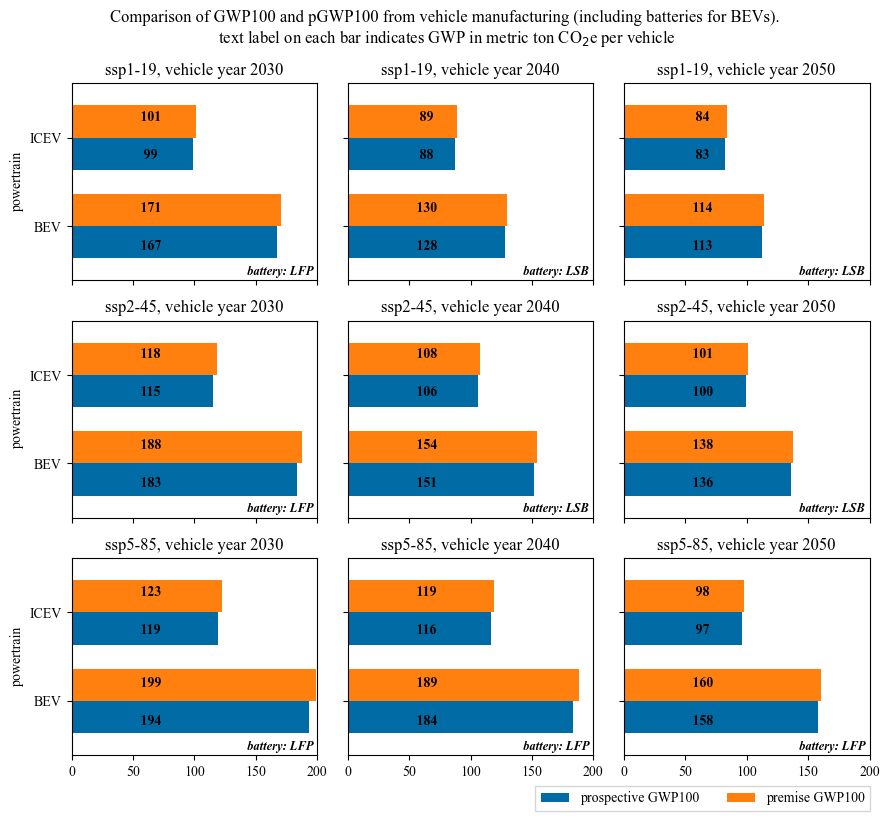

In [16]:
fig, axs = plt.subplots(3, 3, figsize=(9, 8))

# Flatten the axs array to iterate over the subplots
axs = axs.flatten()

for i in range(len(df_plot)) :

    ax = axs[i]
    axs[i].grid(True, linestyle='--', linewidth=0.5, color='gray')
    axs[i].set_xlim(0,200) 
    
    df = df_plot[i]
    ddf = df[['powertrain', 'LCIA_m', 'tCO2e_per_truck']]    
    pivot_df = ddf.pivot_table(index='powertrain', columns='LCIA_m', values='tCO2e_per_truck', aggfunc='sum')
    subtitle = str(df["SSP"][0]) + ", vehicle year " + str(df["Year"][0] )
    
    pivot_df.plot(kind='barh', ax=ax, legend=False, title =subtitle, width=0.73 )
    axs[i].set_title(subtitle)
    
    bev_prem_gwp100 = int(round(df.iloc[0,4]/1000, 0))
    bev_p_gwp100= int(round(df.iloc[1,4]/1000, 0))
    icev_prem_gwp100 = int(round(df.iloc[2,4]/1000, 0))
    icev_p_gwp100 = int(round(df.iloc[3,4]/1000, 0))
    axs[i].text(63, -0.23, f' {bev_p_gwp100}', ha='center', va='center', fontsize=10, fontweight='bold', color='black')
    axs[i].text(63, 0.2, f' {bev_prem_gwp100}', ha='center', va='center', fontsize=10, fontweight='bold', color='black')
    axs[i].text(63, 0.8, f' {icev_p_gwp100}', ha='center', va='center', fontsize=10, fontweight='bold', color='black')
    axs[i].text(63, 1.23, f' {icev_prem_gwp100}', ha='center', va='center', fontsize=10, fontweight='bold', color='black')
    ### adding what best battery is adopted: 
    axs[i].text(140, -0.55 , f' battery: {bat_lable[i]} ',  fontsize=9, fontweight='bold', color='black', fontstyle='italic')

    # Set y-axis to nothing if not left panels
    if i % 3 != 0:  
        axs[i].set_yticklabels([])
        axs[i].set_ylabel('') 

    """
    if i == 0 or i == 3 or i == 6 :  
        axs[i].set_xlim(0,200) 
    if i == 1 or i == 4 or i == 7 :   
        axs[i].set_xlim(0,200) 
    if i == 2 or i == 5 or i == 8 :  
        axs[i].set_xlim(0,165) 
    """   
    if i<6:
            axs[i].set_xticklabels([])  
    
label = ['prospective GWP100', 'premise GWP100']
#label[9] = "switch_P: gtruck_BEV_battery_tech"
fig.legend(label, loc='lower right', bbox_to_anchor=(0.98, -0.03), fancybox=False,  ncol=2)
tt1 = r'Comparison of GWP100 and pGWP100 from vehicle manufacturing (including batteries for BEVs).' 
#tt2 = '\n BEVs adopt the battery technology with the lowest GWP100 that is TRL-compliant for the given year and scenario.'
tt3 = '\n text label on each bar indicates GWP in metric ton CO$_2$e per vehicle'
fig.suptitle(tt1+tt3, fontsize=12)
plt.tight_layout()

plt.savefig('output/Fig5b_GWP100vsPGWP100.jpg', dpi=300, bbox_inches='tight')
plt.show()